In [1]:
import os
import random
import numpy as np
import pandas as pd
import time
from matplotlib import pyplot as plt

In [2]:
from SALib.sample import saltelli
from SALib.analyze import sobol

In [3]:
import warnings
warnings.filterwarnings('ignore')

### **Treatment-induced system dynamics**

In [4]:
# system parameters for training
problem = {
    'num_vars': 15,
    # index       0         1        2        3          4          5          6        7      8     9     10    11    12    13    14
    'names': ['alpha1', 'alpha2', 'beta1', 'beta2', 'init_x1', 'init_x2', 'init_a0', 'gamma', 'k1', 'k2', 'k3', 'k4', 'm1', 'c1', 'c2'],
    'bounds': [[0.01235, 0.03705],        # alpha1
               [0.012975, 0.038925],      # alpha2
               [0.004025, 0.012075],      # beta1
               [0.00975, 0.02925],        # beta2
               [7.5, 22.5],               # init X1
               [0.05, 0.15],              # init X2
               [15, 45],                  # init a0
               [0.04, 0.12],              # y0 = gamma
               [0, 0.5],                  # k1
               [1, 3],                    # k2 
               [4, 12],                   # k3
               [0.25, 0.75],              # k4
               [0.000025, 0.000075],      # m1
               [0.5, 1.5],                # c1 
               [0.5, 1.5]]                # c2
}

In [5]:
param_values = saltelli.sample(problem, 8) # generate random combination of params, len(param_values) = 256

In [6]:
'''
n_samples = 200

indices = np.random.choice(len(param_values), size=n_samples, replace=False)
sampled_params = param_values[indices]

sampled_params[0][0]
'''
param_values[0][0]

np.float64(0.014665625)

In [7]:
def On_Treatment(A, X1, X2, Y, dY, Week, params):
    '''
    a, x1, x2, y, p1, q1, p2, q2, m: lists of the variable values over time
    Week: time of observation that starts to accumulate at the beginning of the simulation
    '''

    alpha1 = params[0]; alpha2 = params[1]; beta1 = params[2]; beta2 = params[3]; a0 = params[6]
    gamma = params[7]; k1 = params[8]; k2 = params[9]; k3 = params[10]; k4 = params[11]
    m1 = params[12]; c1 = params[13]; c2 = params[14]
    
    # iteration paramters
    h = 2                      # step length
    Starting_Time = Week*7
    Ending_Time = (Week+1)*7   # (e.g. week 0 -> i will loop for 7 days)
    
    for t in range(Starting_Time, Ending_Time):
        a_tplus1 = (-gamma*(A[t]-a0)-gamma*a0*1)*h+A[t] # u(t)=1, on-treatment
        A.append(a_tplus1)

        p1_t = k1+(1-k1)*(A[t+1]/(A[t+1]+k2))
        q1_t = k3+(1-k3)*(A[t+1]/(A[t+1]+k4))
        p2_t = 1-(A[t+1]/a0)
        q2_t = 1
        m_t = m1*(1-(A[t+1]/a0))
        
        x1_tplus1 = ((alpha1*p1_t-beta1*q1_t-m_t)*X1[t])*h+X1[t]; X1.append(x1_tplus1)
        x2_tplus1 = (m_t*X1[t]+(alpha2*p2_t-beta2*q2_t)*X2[t])*h+X2[t]; X2.append(x2_tplus1)

        dy_t = c1*((alpha1*p1_t-beta1*q1_t-m_t)*X1[t+1]) + c2*(m_t*X1[t+1]+(alpha2*p2_t-beta2*q2_t)*X2[t+1])
        dY.append(dy_t)
        
        y_tplus1 = c1*X1[t+1]+c2*X2[t+1]
        Y.append(y_tplus1)

    return A, X1, X2, Y, dY

In [8]:
def Off_Treatment(A, X1, X2, Y, dY, Week, params):
    '''
    a, x1, x2, y, p1, q1, p2, q2, m: lists of the variable values over time
    Week: time of observation that starts to accumulate at the beginning of the simulation
    '''    
    
    alpha1 = params[0]; alpha2 = params[1]; beta1 = params[2]; beta2 = params[3]; a0 = params[6]
    gamma = params[7]; k1 = params[8]; k2 = params[9]; k3 = params[10]; k4 = params[11]
    m1 = params[12]; c1 = params[13]; c2 = params[14]
    
    # iteration paramters 
    h = 2
    Starting_Time = Week*7
    Ending_Time = (Week+1)*7
    
    for t in range(Starting_Time, Ending_Time):
        a_tplus1 = (-gamma*(A[t]-a0)-gamma*a0*0)*h+A[t] # u(t)=0, off-treatment
        A.append(a_tplus1)

        p1_t = k1+(1-k1)*(A[t+1]/(A[t+1]+k2))
        q1_t = k3+(1-k3)*(A[t+1]/(A[t+1]+k4))
        p2_t = 1-(A[t+1]/a0)
        q2_t = 1
        m_t = m1*(1-(A[t+1]/a0))
        
        x1_tplus1 = ((alpha1*p1_t-beta1*q1_t-m_t)*X1[t])*h+X1[t]; X1.append(x1_tplus1)
        x2_tplus1 = (m_t*X1[t]+(alpha2*p2_t-beta2*q2_t)*X2[t])*h+X2[t]; X2.append(x2_tplus1)

        dy_t = c1*((alpha1*p1_t-beta1*q1_t-m_t)*X1[t+1]) + c2*(m_t*X1[t+1]+(alpha2*p2_t-beta2*q2_t)*X2[t+1])
        dY.append(dy_t)
        
        y_tplus1 = c1*X1[t+1]+c2*X2[t+1]
        Y.append(y_tplus1)

    return A, X1, X2, Y, dY

### **Q-Learning**

In [9]:
# q_table_file = r'C:\Users\amp87\Desktop\QLearning\QLearning\q_table.csv'

N_STATES = 4*12*5*4    # 4 weeks/month * 12 months/year * 5 years * 4 ordinal data (high, medium, proper, low)
EPSILON = 1.0          # init value, < EPSILON then greedy
EPSILON_decay = 0.999  # decay factor, < EPSILON then greedy (allows the random exploring)
ALPHA = 0.05           # learning rate
GAMMA = 0.9            # discount factor

MAX_EPISODES = 15000   # maximum training episodes
Y_UPPER = 10           # serum PSA concentration y(t)'s upper bound, threshold for biomedical recurrence (unit: ng/10mL)
# Y_LOWER = 1          # y(t) lower bound

ACTIONS = ['med', 'non_med']  # possible actions, medication (on), non-medication (off)

In [10]:
def decode_state(state_index):
    ordinal = state_index % 4           # Ordinal (0: low, 1: proper, 2: medium, 3: high)
    week = (state_index//4) % 4         # Week    (0 to 3 within a month)
    month = (state_index//(4*4)) % 12   # Month   (0 to 11 within a year)
    year = state_index // (4*4*12)      # Year    (0 to 4 within 5 years)
    return year, month, week, ordinal
    
def is_terminal_state(state_index):
    year, month, week, _ = decode_state(state_index)
    return year == 4 and month == 11 and week == 3

##### **Q-Table**

In [11]:
# initialie the Q-table (or use an existing one)

Q_table_file = '/Users/ekeulseuji/Downloads/Q_table_Case3.csv'

def build_q_table(n_States, Actions):
    '''
    if os.path.exists('/Users/ekeulseuji/Downloads/Q_table.csv'):
        Table = pd.read_csv(Q_table_file)
    else: 
        Table = pd.DataFrame(np.zeros((n_States, len(Actions))), 
                             columns = Actions)
    '''
    Table = pd.DataFrame(np.zeros((n_States, len(Actions))), columns = Actions)
    return Table

##### **Action**

In [12]:
def choose_action(State, Q_table, EPSILON_n_iter):
    State_Actions = Q_table.iloc[State, :]  # all posible actions at the current (input) state

    # non-greedy, or the state hasn't been explored yet -> act randomly
    if (np.random.uniform() < EPSILON*(EPSILON_decay**EPSILON_n_iter)) or (State_Actions.all() == 0):  
        Action_SELECTED = np.random.choice(ACTIONS)
    else:
        Action_SELECTED = State_Actions.idxmax()  # acts greedy
    
    return Action_SELECTED, EPSILON_n_iter

In [13]:
def choose_best_action(State, Q_table):
    State_Actions = Q_table.iloc[State, :]  # all posible actions at the current (input) state
    Action_SELECTED = State_Actions.idxmax()  # acts greedy
    return Action_SELECTED

##### **State**

In [14]:
# helper function to categorize serum PSA levels (y_t) into ordinal categories
def y_to_scope(y_t):
    '''
    returns the scope: Ordinal category (0: low, 1: proper, 2: medium, 3: high)
    '''
    if 0 <= y_t < 10:
        scope = 0  # Low
    elif 10 <= y_t < 20:
        scope = 1  # Proper
    elif 20 <= y_t < 30:
        scope = 2  # Medium
    elif 30 <= y_t:
        scope = 3  # High

    return scope

In [15]:
# helper function to check whether the list has any element >= the upper threhold
# cannot just do: return True if any(elem >= Y_UPPER for elem in in_list) else False
def check_biomedical_recurrence(in_PSA_list, in_deriv_PSA):
    # serum PSA level >= 2 ng/mL and dY >= 0 for **2 consistent weeks (14 days)**

    # <21 days
    if len(in_PSA_list) < 21:
        return False
        
    else:  
        biom_rec = True
        for day in range(len(in_PSA_list)-22, len(in_PSA_list)-1):
            if in_PSA_list[day] <= Y_UPPER or in_deriv_PSA[day] <= 0:
                biom_rec = False
        return biom_rec

In [16]:
# determine the new state (New_State) and immediate reward (Reward) of an agent after taking an action
def get_env_feedback(Current_State, Action, Week, A, X1, X2, Y, dY, params):
    '''
    do switching, check med-/no med-induced dynamics 
    Current_State: current dyn.
    Action: 'med' or 'non_med'
    Week: current week
    A, X1, X2, Y, dY: lists containing the past cond.s
    '''
    if Action == 'med':
        A, X1, X2, Y, dY = On_Treatment(A, X1, X2, Y, dY, Week, params)
        action_cost = -5  # med
    else:
        A, X1, X2, Y, dY = Off_Treatment(A, X1, X2, Y, dY, Week, params)
        action_cost = 3   # no med

    Current_y = Y[-1]                  # the current serum PSA level at the end of the week
    PSA_scope = y_to_scope(Current_y)  # action induced PSA level (0: low, 1: proper, 2: medium, 3: high)
    
    # biochemical reccurrence?
    is_rec = check_biomedical_recurrence(Y, dY)
    
    # check terminal condition: environment ends when the state corresponds to the last time step (end of 5 years, i.e., week 240)
    is_finished = (Week >= (N_STATES // 4) - 1)

    if is_rec:
        New_State = -1
        Reward = -100
    elif is_finished:
        New_State = -1
        Reward = 100   # successful long-living rewards: recurrence-free survival(RFS), reaches the terminal
    else:
        # N_STATES: [Year][Month][Week][Ordinal] -> 4 * 12 * 5 * 4
        next_week_base = (Week + 1) * 4
        New_State = next_week_base + PSA_scope
        
        # interm. rewards: low PSA, med withdraw
        Reward = action_cost + (2-PSA_scope)

    return New_State, Reward, A, X1, X2, Y, dY

### **The Main QL Algorithm (Sensitivity Analysis Ver.) + Q-table Goodness Score Calculator**

In [17]:
def evaluate_Q_tab(Q_table, params, n_patients=100):
    results = []

    for i in range(n_patients):
        np.random.seed(i)

        Week = 0
        a_init = params[6]; x1_init = params[4]; x2_init = params[5]
        m1 = params[12]; c1 = params[13]; c2 = params[14]
        A, X1, X2 = [a_init], [x1_init], [x2_init]
        Y = [c1*X1[0] + c2*X2[0]]
        dY = []
        Action_Punishment = []
        action_punishment = 0
        
        while True:
            state = y_to_scope(Y[-1])
            action = choose_best_action(state, Q_table)
            if action == 'med':
                action_punishment = action_punishment + 1

            New_State, Reward, A, X1, X2, Y, dY = get_env_feedback(state, action, Week, A, X1, X2, Y, dY, params)

            Week += 1
            Action_Punishment.append(action_punishment)

            if New_State == -1 or Week >= (N_STATES // 4):
                break

        results.append({"weeks": Week, "final_psa": Y[-1],
                        "avg_psa": np.mean(Y),
                        "avg_act_puni": np.mean(Action_Punishment)})

    df = pd.DataFrame(results)

    Q_tab_goodness_score = (7*df["weeks"].mean() - 0.1*df["avg_psa"].mean() - 0.5*df["avg_act_puni"].mean())

    return Q_tab_goodness_score

In [18]:
def RL_training_process(params, nth_set):
    # build (initialize) the Q table
    Q_table = build_q_table(N_STATES, ACTIONS) 

    # save the best Q table
    best_Q_score = -np.inf
    best_Q = None

    nth_set = nth_set + 1
    EPSILON_n_iter = 0
    best_Q_tables = []
    best_weeks_so_far = 0
    
    for episode in range(MAX_EPISODES+1):
        # init env
        Week = 0
        EPSILON_n_iter = EPSILON_n_iter + 1 # starts the decay for every training iteration
        terminate = False
        
        # init params
        a_init = params[6]; x1_init = params[4]; x2_init = params[5]
        m1 = params[12]; c1 = params[13]; c2 = params[14]

        A, X1, X2 = [a_init], [x1_init], [x2_init]
        Y = [c1*X1[0] + c2*X2[0]]
        dY = []
        Action_List_QL = []
        med_punishment = 0
        
        Current_State = y_to_scope(Y[0]) # init states (0-3)

        while not terminate:
            Current_Action, EPSILON_n_iter = choose_action(Current_State, Q_table, EPSILON_n_iter)
            Action_List_QL.extend([Current_Action]*7)
            if Current_Action == 'med':
                med_punishment = med_punishment + 1
            
            # interact with the env
            New_State, Reward, A, X1, X2, Y, dY = get_env_feedback(Current_State, Current_Action, Week, A, X1, X2, Y, dY, params)
            
            # update Q-table
            Q_val_predict = Q_table.loc[Current_State, Current_Action]
            
            if New_State != -1:
                Q_val_target = Reward + GAMMA * Q_table.iloc[New_State, :].max()
            else:
                Q_val_target = Reward
                terminate = True
                if episode !=0 and episode%15000 == 0:
                    # print(f'Episode: {episode} | Weeks Survived: {Week} | Final PSA: {Y[-1]:.2f}')
                    print(nth_set, "th set 's best week:", best_weeks_so_far)
                    result_weeks.append(best_weeks_so_far)

                current_weeks = Week
        
                if current_weeks > best_weeks_so_far:
                    # better survival weeks; clear the previous records
                    best_weeks_so_far = current_weeks
                    best_Q_tables = [{"weeks": current_weeks, "psa": Y.copy(), "Q_tab": Q_table.copy(),
                                      "act_list": Action_List_QL.copy(), "med_puni": med_punishment}]
            
                elif current_weeks == best_weeks_so_far:
                    # same number of survival weeks; retain all Q-tables that reach this number of weeks
                    best_Q_tables.append({"weeks": current_weeks, "psa": Y.copy(), "Q_tab": Q_table.copy(),
                                          "act_list": Action_List_QL.copy(), "med_puni": med_punishment})

            Q_table.loc[Current_State, Current_Action] += ALPHA * (Q_val_target - Q_val_predict)
            
            # state shift
            Current_State = New_State
            Week += 1
            
            # cool
            if Week >= (N_STATES // 4):
                terminate = True


    # cannot make it (× progression-free survival ×) till the end of the 1st week (??!
    if len(best_Q_tables) < 1:
        return 0
    
    else:
        df = pd.DataFrame(best_Q_tables)

        lowest_med_punishment = np.inf
        best_of_the_bests = None

        for idx, row in df.iterrows():
            if row['med_puni'] < lowest_med_punishment: # choose the one with the best medication strategy
                best_of_the_bests = row

        best_Q_table = best_of_the_bests["Q_tab"]
        best_PSA_ctrl = best_of_the_bests["psa"]
        best_Act_list = best_of_the_bests["act_list"]

        # evaluate the best_Q_table (progression-free survival throughout 5 years + lowest number of dosing actions)        
        best_Q_table_goodness_score = evaluate_Q_tab(best_Q_table, params)

        return best_Q_table_goodness_score, nth_set

In [19]:
results = []
corresponding_set_index = 0
result_weeks = []
for single_param_set in param_values:
    Q_score, corresponding_set_index = RL_training_process(single_param_set, corresponding_set_index)
    results.append(Q_score)

1 th set 's best week: 239
2 th set 's best week: 239
3 th set 's best week: 239
4 th set 's best week: 239
5 th set 's best week: 230
6 th set 's best week: 239
7 th set 's best week: 239
8 th set 's best week: 207
9 th set 's best week: 148
10 th set 's best week: 239
11 th set 's best week: 239
12 th set 's best week: 233
13 th set 's best week: 111
14 th set 's best week: 230
15 th set 's best week: 239
16 th set 's best week: 239
17 th set 's best week: 239
18 th set 's best week: 239
19 th set 's best week: 239
20 th set 's best week: 239
21 th set 's best week: 239
22 th set 's best week: 239
23 th set 's best week: 239
24 th set 's best week: 239
25 th set 's best week: 239
26 th set 's best week: 239
27 th set 's best week: 239
28 th set 's best week: 239
29 th set 's best week: 239
30 th set 's best week: 239
31 th set 's best week: 239
32 th set 's best week: 239
33 th set 's best week: 121
34 th set 's best week: 174
35 th set 's best week: 239
36 th set 's best week: 17
37

In [20]:
SA_out = sobol.analyze(problem, np.array(results))

In [21]:
SA_out['S1']

array([ 1.35311929e-01,  1.56818894e-02, -1.51583548e-02,  8.46507422e-03,
        8.86809827e-01,  2.31490672e-03, -5.58374274e-03, -1.62908894e-01,
        1.48039647e-02, -2.67539090e-03,  1.91635760e-02,  5.48628984e-03,
        2.80323869e-06,  8.58392134e-01, -7.71549872e-04])

In [22]:
results_df = pd.DataFrame({
    'Parameter': problem['names'],
    'S1': SA_out['S1'],
    'S1_conf': SA_out['S1_conf'],
    'ST': SA_out['ST'],
    'ST_conf': SA_out['ST_conf']})

print(results_df)

   Parameter        S1    S1_conf            ST       ST_conf
0     alpha1  0.135312   0.946562  5.675008e-01  6.413035e-01
1     alpha2  0.015682   0.099109  2.304062e-01  4.198418e-01
2      beta1 -0.015158   7.152886  9.067421e-01  2.474070e+01
3      beta2  0.008465   0.362008  9.015635e-04  3.853320e-02
4    init_x1  0.886810   1.213669  8.685513e-01  7.418917e-01
5    init_x2  0.002315   0.098912  6.732550e-05  2.877521e-03
6    init_a0 -0.005584   0.942714  9.581666e-04  1.208045e-01
7      gamma -0.162909  11.165317  4.225539e-01  2.651797e+01
8         k1  0.014804   0.627795  2.705327e-03  1.156050e-01
9         k2 -0.002675   0.467217  4.164001e-04  3.879985e-02
10        k3  0.019164   0.737114  3.821459e-03  1.553440e-01
11        k4  0.005486   1.275559  5.351776e-03  3.618230e-01
12        m1  0.000003   0.000142  1.884743e-10  5.790459e-09
13        c1  0.858392   1.100843  8.635994e-01  7.546091e-01
14        c2 -0.000772   0.032963  7.481866e-06  3.197780e-04


In [24]:
results_df = pd.DataFrame({
    'Parameter': problem['names'],
    'S1': SA_out['S1'],
    'S1_conf': SA_out['S1_conf'],
    'ST': SA_out['ST'],
    'ST_conf': SA_out['ST_conf']
})

print("="*60)
print("SENSITIVITY ANALYSIS RESULTS")
print("="*60)
print(results_df.round(4).to_string())

print("\n" + "="*60)
print("PARAMETERS RANKED BY IMPORTANCE (S1)")
print("="*60)
ranked = results_df.sort_values('S1', ascending=False)
for i, (_, row) in enumerate(ranked.iterrows(), 1):
    print(f"{i:2d}. {row['Parameter']:12s}: S1 = {row['S1']:8.4f}, ST = {row['ST']:8.4f}")

SENSITIVITY ANALYSIS RESULTS
   Parameter      S1  S1_conf      ST  ST_conf
0     alpha1  0.1353   0.9466  0.5675   0.6413
1     alpha2  0.0157   0.0991  0.2304   0.4198
2      beta1 -0.0152   7.1529  0.9067  24.7407
3      beta2  0.0085   0.3620  0.0009   0.0385
4    init_x1  0.8868   1.2137  0.8686   0.7419
5    init_x2  0.0023   0.0989  0.0001   0.0029
6    init_a0 -0.0056   0.9427  0.0010   0.1208
7      gamma -0.1629  11.1653  0.4226  26.5180
8         k1  0.0148   0.6278  0.0027   0.1156
9         k2 -0.0027   0.4672  0.0004   0.0388
10        k3  0.0192   0.7371  0.0038   0.1553
11        k4  0.0055   1.2756  0.0054   0.3618
12        m1  0.0000   0.0001  0.0000   0.0000
13        c1  0.8584   1.1008  0.8636   0.7546
14        c2 -0.0008   0.0330  0.0000   0.0003

PARAMETERS RANKED BY IMPORTANCE (S1)
 1. init_x1     : S1 =   0.8868, ST =   0.8686
 2. c1          : S1 =   0.8584, ST =   0.8636
 3. alpha1      : S1 =   0.1353, ST =   0.5675
 4. k3          : S1 =   0.0192, ST =   

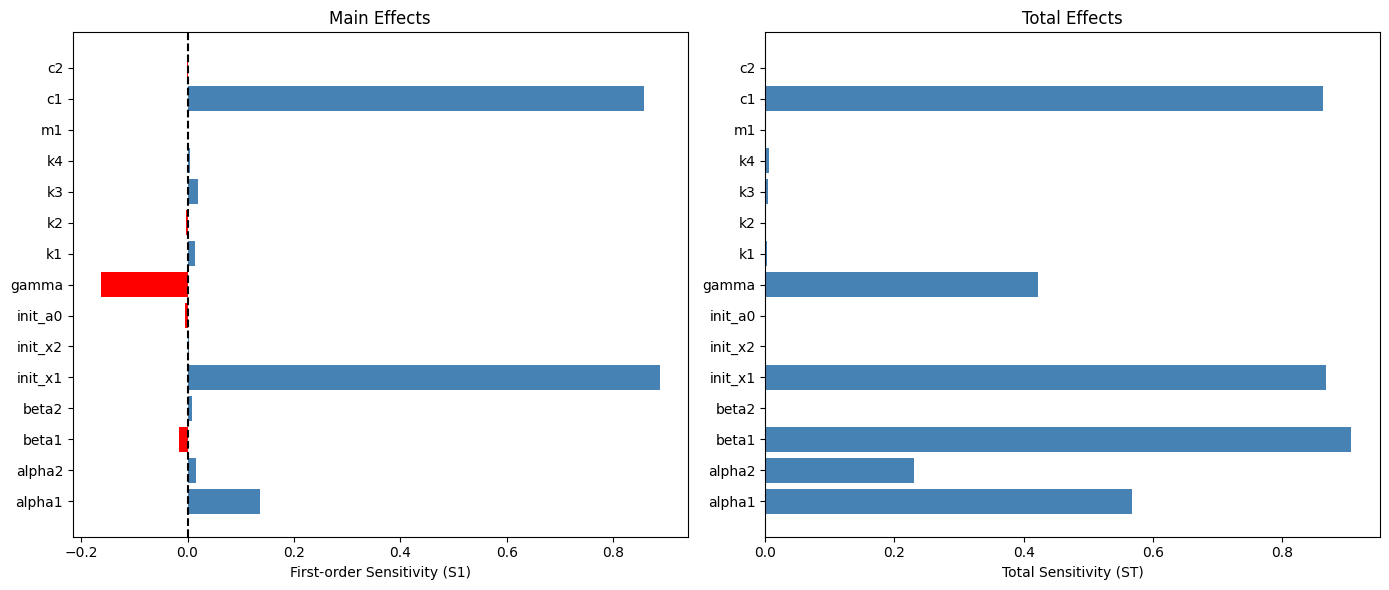

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# S1 plot
colors = ['red' if x < 0 else 'steelblue' for x in results_df['S1']]
axes[0].barh(results_df['Parameter'], results_df['S1'], color=colors)
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].set_xlabel('First-order Sensitivity (S1)')
axes[0].set_title('Main Effects')

# ST plot
axes[1].barh(results_df['Parameter'], results_df['ST'], color='steelblue')
axes[1].set_xlabel('Total Sensitivity (ST)')
axes[1].set_title('Total Effects')

plt.tight_layout()
plt.show()

In [27]:
total = len(result_weeks)
success = sum(1 for w in result_weeks if w >= 239)
partial = sum(1 for w in result_weeks if 95 <= w < 239) # 2 years
failure = sum(1 for w in result_weeks if w < 95)

print(f"Total parameter sets: {total}")
print(f"Success (240 weeks): {success} ({success/total*100:.1f}%)")
print(f"Partial success (96-239 weeks): {partial} ({partial/total*100:.1f}%)")
print(f"Early failure (<96 weeks): {failure} ({failure/total*100:.1f}%)")
print(f"Mean weeks: {np.mean(result_weeks):.1f} ± {np.std(result_weeks):.1f}")
print(f"Median weeks: {np.median(result_weeks):.1f}")

Total parameter sets: 256
Success (240 weeks): 91 (35.5%)
Partial success (96-239 weeks): 42 (16.4%)
Early failure (<96 weeks): 123 (48.0%)
Mean weeks: 124.5 ± 99.3
Median weeks: 101.5


In [28]:
# link the resulting weeks to the 256 sets of param_values
results_df = pd.DataFrame(param_values, columns=problem['names'])
results_df['best_weeks'] = result_weeks
results_df['success'] = results_df['best_weeks'] >= 239

success_params = results_df[results_df['success']].mean()
failure_params = results_df[~results_df['success']].mean()

comparison = pd.DataFrame({
    'Success_Group': success_params,
    'Failure_Group': failure_params,
    'Difference': success_params - failure_params
})
print(comparison)

            Success_Group  Failure_Group    Difference
alpha1           0.019212       0.027727 -8.514632e-03
alpha2           0.026244       0.025788  4.562637e-04
beta1            0.009844       0.007451  2.393287e-03
beta2            0.019038       0.018809  2.285714e-04
init_x1         13.016827      15.366477 -2.349650e+00
init_x2          0.112672       0.097860  1.481185e-02
init_a0         28.258929      29.505682 -1.246753e+00
gamma            0.087390       0.079803  7.587080e-03
k1               0.311985       0.240057  7.192807e-02
k2               2.183379       1.801894  3.814852e-01
k3               7.502747       8.274242 -7.714952e-01
k4               0.460680       0.497443 -3.676324e-02
m1               0.000050       0.000050  1.332001e-07
c1               0.996223       1.002083 -5.860806e-03
c2               0.952266       1.074811 -1.225441e-01
best_weeks     239.000000      61.375758  1.776242e+02
success          1.000000       0.000000  1.000000e+00


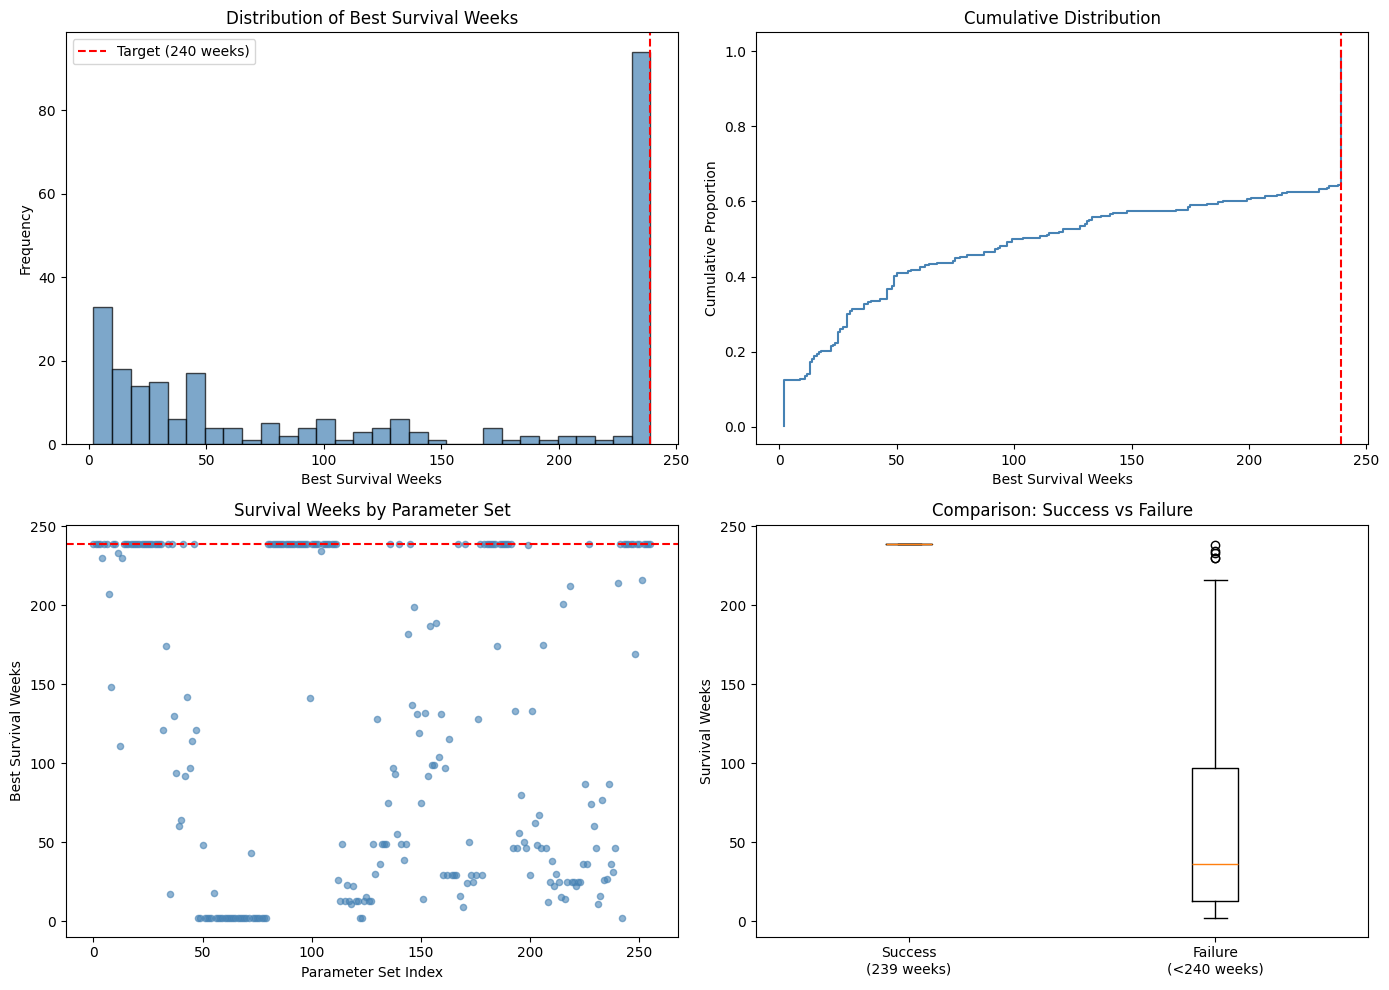

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
ax1.hist(result_weeks, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(x=239, color='red', linestyle='--', label='Target (240 weeks)')
ax1.set_xlabel('Best Survival Weeks')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Best Survival Weeks')
ax1.legend()

ax2 = axes[0, 1]
sorted_weeks = np.sort(result_weeks)
cumulative = np.arange(1, len(sorted_weeks)+1) / len(sorted_weeks)
ax2.step(sorted_weeks, cumulative, where='post', color='steelblue')
ax2.axvline(x=239, color='red', linestyle='--')
ax2.set_xlabel('Best Survival Weeks')
ax2.set_ylabel('Cumulative Proportion')
ax2.set_title('Cumulative Distribution')

ax3 = axes[1, 0]
ax3.scatter(range(len(result_weeks)), result_weeks, alpha=0.6, s=20, c='steelblue')
ax3.axhline(y=239, color='red', linestyle='--')
ax3.set_xlabel('Parameter Set Index')
ax3.set_ylabel('Best Survival Weeks')
ax3.set_title('Survival Weeks by Parameter Set')

ax4 = axes[1, 1]
success_weeks = [w for w in result_weeks if w >= 239]
failure_weeks = [w for w in result_weeks if w < 239]
bp = ax4.boxplot([success_weeks, failure_weeks], labels=['Success\n(239 weeks)', 'Failure\n(<240 weeks)'])
ax4.set_ylabel('Survival Weeks')
ax4.set_title('Comparison: Success vs Failure')

plt.tight_layout()
plt.savefig('survival_analysis.png', dpi=150)
plt.show()

In [31]:
from scipy.stats import ttest_ind

print("\n=== Parameter differences between success and failure groups ===")
for param in problem['names']:
    success_vals = results_df[results_df['success']][param]
    failure_vals = results_df[~results_df['success']][param]
    
    t_stat, p_value = ttest_ind(success_vals, failure_vals)
    
    print(f"{param:12s}: Success mean = {success_vals.mean():8.4f}, "
          f"Failure mean = {failure_vals.mean():8.4f}, "
          f"p = {p_value:.4f}")


=== Parameter differences between success and failure groups ===
alpha1      : Success mean =   0.0192, Failure mean =   0.0277, p = 0.0000
alpha2      : Success mean =   0.0262, Failure mean =   0.0258, p = 0.6418
beta1       : Success mean =   0.0098, Failure mean =   0.0075, p = 0.0000
beta2       : Success mean =   0.0190, Failure mean =   0.0188, p = 0.7551
init_x1     : Success mean =  13.0168, Failure mean =  15.3665, p = 0.0000
init_x2     : Success mean =   0.1127, Failure mean =   0.0979, p = 0.0001
init_a0     : Success mean =  28.2589, Failure mean =  29.5057, p = 0.2682
gamma       : Success mean =   0.0874, Failure mean =   0.0798, p = 0.0111
k1          : Success mean =   0.3120, Failure mean =   0.2401, p = 0.0001
k2          : Success mean =   2.1834, Failure mean =   1.8019, p = 0.0000
k3          : Success mean =   7.5027, Failure mean =   8.2742, p = 0.0102
k4          : Success mean =   0.4607, Failure mean =   0.4974, p = 0.0495
m1          : Success mean =   0.0

In [33]:
results_df = pd.DataFrame({
    'Parameter': problem['names'],
    'S1': SA_out['S1'],
    'S1_conf': SA_out['S1_conf'],
    'ST': SA_out['ST'],
    'ST_conf': SA_out['ST_conf']
})

print("="*60)
print("SENSITIVITY ANALYSIS RESULTS")
print("="*60)
print(results_df.round(4).to_string())

print("\n" + "="*60)
print("PARAMETERS RANKED BY IMPORTANCE (S1)")
print("="*60)
ranked = results_df.sort_values('S1', ascending=False)
for i, (_, row) in enumerate(ranked.iterrows(), 1):
    print(f"{i:2d}. {row['Parameter']:12s}: S1 = {row['S1']:8.4f}, ST = {row['ST']:8.4f}")

SENSITIVITY ANALYSIS RESULTS
   Parameter      S1  S1_conf      ST  ST_conf
0     alpha1  0.1353   0.9466  0.5675   0.6413
1     alpha2  0.0157   0.0991  0.2304   0.4198
2      beta1 -0.0152   7.1529  0.9067  24.7407
3      beta2  0.0085   0.3620  0.0009   0.0385
4    init_x1  0.8868   1.2137  0.8686   0.7419
5    init_x2  0.0023   0.0989  0.0001   0.0029
6    init_a0 -0.0056   0.9427  0.0010   0.1208
7      gamma -0.1629  11.1653  0.4226  26.5180
8         k1  0.0148   0.6278  0.0027   0.1156
9         k2 -0.0027   0.4672  0.0004   0.0388
10        k3  0.0192   0.7371  0.0038   0.1553
11        k4  0.0055   1.2756  0.0054   0.3618
12        m1  0.0000   0.0001  0.0000   0.0000
13        c1  0.8584   1.1008  0.8636   0.7546
14        c2 -0.0008   0.0330  0.0000   0.0003

PARAMETERS RANKED BY IMPORTANCE (S1)
 1. init_x1     : S1 =   0.8868, ST =   0.8686
 2. c1          : S1 =   0.8584, ST =   0.8636
 3. alpha1      : S1 =   0.1353, ST =   0.5675
 4. k3          : S1 =   0.0192, ST =   

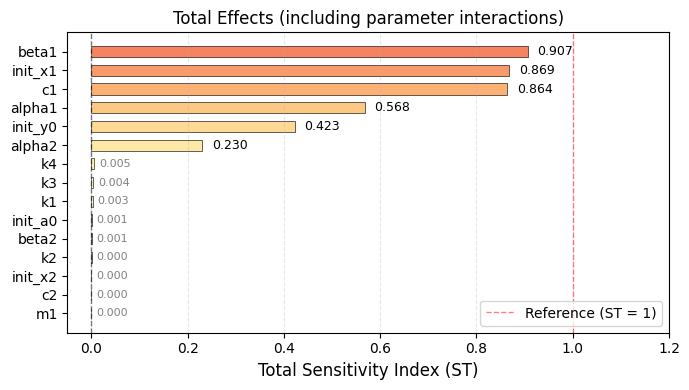

In [43]:
fig, ax = plt.subplots(figsize=(7,4))

sorted_idx = results_df['ST'].argsort()
params_sorted = results_df['Parameter'].iloc[sorted_idx]
st_sorted = results_df['ST'].iloc[sorted_idx]

colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(params_sorted)))
# colors = 'teal'
# colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(params_sorted)))

bars = ax.barh(params_sorted, st_sorted, 
               height=0.6,
               color=colors, 
               edgecolor='black', 
               linewidth=0.5,
               alpha=0.85)

ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=1, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Reference (ST = 1)')

for bar, st_val in zip(bars, st_sorted):
    if st_val > 0.1:
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
                f'{st_val:.3f}', va='center', fontsize=9)
    else:
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{st_val:.3f}', va='center', fontsize=8, color='gray')

ax.set_xlabel('Total Sensitivity Index (ST)', fontsize=12)
ax.set_title('Total Effects (including parameter interactions)', fontsize=12)

x_max = max(st_sorted.max(), 1.2)
ax.set_xlim(-0.05, x_max)

ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('/Users/ekeulseuji/Downloads/tot_effects.pdf', bbox_inches='tight')
plt.show()

In [42]:
results_df['Parameter'] = results_df['Parameter'].replace('gamma', 'init_y0')
results_df.loc[results_df['Parameter'] == 'gamma', 'Parameter'] = 'init_y0'

print(results_df[results_df['Parameter'] == 'init_y0'])

  Parameter        S1    S1_conf        ST    ST_conf
7   init_y0 -0.162909  11.165317  0.422554  26.517969
